# **ANN 5 – Implement a Perceptron to classify 2D linearly separable data and visualize its decision boundary.**

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
class BidirectionalAssociativeMemory:
    """
    A Bidirectional Associative Memory (BAM) network.
    This network learns to associate pairs of bipolar vectors.
    """
    def __init__(self):
        self.W = None

    def _activation(self, data):
        """Activation function to convert a vector to bipolar form (+1, -1)."""
        return np.where(data >= 0, 1, -1)

    def train(self, patterns_X, patterns_Y):
        """Trains the BAM using the Hebbian learning rule."""
        if patterns_X.shape[0] != patterns_Y.shape[0]:
            raise ValueError("The number of input and output patterns must be equal.")
        self.W = np.dot(patterns_X.T, patterns_Y)
        print("Training complete. Weight matrix created.")

    def recall_forward(self, pattern_x):
        """Performs a forward pass to recall an associated pattern Y from an input X."""
        if self.W is None:
            raise RuntimeError("The model has not been trained yet.")
        return self._activation(np.dot(pattern_x, self.W))

    def recall_backward(self, pattern_y):
        """Performs a backward pass to recall an associated pattern X from an input Y."""
        if self.W is None:
            raise RuntimeError("The model has not been trained yet.")
        return self._activation(np.dot(pattern_y, self.W.T))

In [10]:
def plot_patterns(original_pattern, noisy_pattern, recalled_pattern):
    """
    Visualizes the original, noisy, and recalled patterns as 2x3 grids.
    """
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    
    # Colormap: black for -1, white for 1
    cmap = plt.cm.get_cmap('gray', 2)

    axes[0].imshow(original_pattern.reshape(2, 3), cmap=cmap, interpolation='nearest')
    axes[0].set_title("Original Pattern (X1)")
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    axes[1].imshow(noisy_pattern.reshape(2, 3), cmap=cmap, interpolation='nearest')
    axes[1].set_title("Noisy Input")
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    
    axes[2].imshow(recalled_pattern.reshape(2, 3), cmap=cmap, interpolation='nearest')
    axes[2].set_title("Recalled Pattern")
    axes[2].set_xticks([])
    axes[2].set_yticks([])
    
    plt.suptitle("BAM Recall from Noisy Input", fontsize=16)
    plt.show()

Training complete. Weight matrix created.

--- Testing with Noisy Input ---
Original X1:  [ 1  1 -1 -1  1  1]
Noisy X1:     [-1 -1 -1 -1  1  1]
Recalled X1:  [ 1  1 -1 -1  1  1]
Successfully recalled original X1? -> True


C:\Users\omshi\AppData\Local\Temp\ipykernel_20836\2555190222.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('gray', 2)


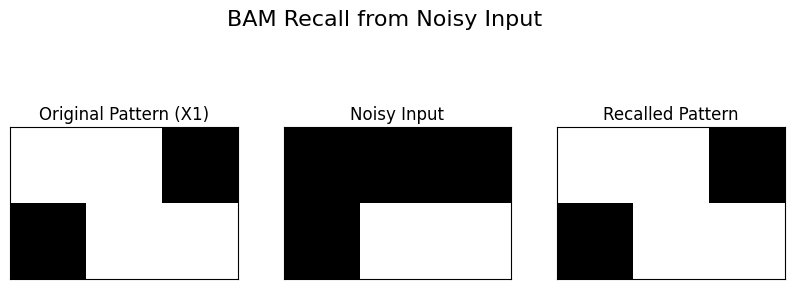

In [11]:
# --- Example Usage ---

if __name__ == "__main__":
    # 1. Define two pairs of bipolar patterns to associate.
    X1 = np.array([1, 1, -1, -1, 1, 1])
    Y1 = np.array([1, -1])
    X2 = np.array([-1, -1, 1, 1, -1, -1])
    Y2 = np.array([-1, 1])

    patterns_X = np.array([X1, X2])
    patterns_Y = np.array([Y1, Y2])

    # 2. Initialize and train the BAM
    bam = BidirectionalAssociativeMemory()
    bam.train(patterns_X, patterns_Y)

    # 3. Test with a noisy pattern
    print("\n--- Testing with Noisy Input ---")
    noisy_X1 = X1.copy()
    noisy_X1[0] = -1 # Flip a bit
    noisy_X1[1] = -1 # Flip another bit
    
    # Perform the recall steps here
    recalled_Y = bam.recall_forward(noisy_X1)
    final_recalled_X = bam.recall_backward(recalled_Y)

    print(f"Original X1:  {X1}")
    print(f"Noisy X1:     {noisy_X1}")
    print(f"Recalled X1:  {final_recalled_X}")
    print(f"Successfully recalled original X1? -> {np.array_equal(final_recalled_X, X1)}")
    
    # 4. Visualize the patterns
    plot_patterns(original_pattern=X1, noisy_pattern=noisy_X1, recalled_pattern=final_recalled_X)